In [1]:
from datasets import load_dataset
swag = load_dataset("apurbapokharel/distractor_deliberation")
swag

DatasetDict({
    train: Dataset({
        features: ['models_used', 'rounds', 'number_of_agents', 'problem', 'gold_diagnosis', 'conversation_id', 'history_current', 'history_neighbour', 'reply', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 5827
    })
    validation: Dataset({
        features: ['models_used', 'rounds', 'number_of_agents', 'problem', 'gold_diagnosis', 'conversation_id', 'history_current', 'history_neighbour', 'reply', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 728
    })
    test: Dataset({
        features: ['models_used', 'rounds', 'number_of_agents', 'problem', 'gold_diagnosis', 'conversation_id', 'history_current', 'history_neighbour', 'reply', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 729
    })
})

In [3]:
swag["train"][3]

{'models_used': ['meta-llama/Llama-3. 1-70B-Instruct'],
 'rounds': 2,
 'number_of_agents': 3,
 'problem': 'You are given the following symptoms joint_pain, vomiting, fatigue, yellowish_skin, dark_urine, loss_of_appetite, abdominal_pain, yellowing_of_eyes. Your task is to diagnose a disease that best matches the symptoms.',
 'gold_diagnosis': 'Hepatitis D',
 'conversation_id': 1047,
 'history_current': "Based on the symptoms you've provided, I would diagnose the disease as Hepatitis. Here's why: * Joint pain and fatigue are common symptoms of hepatitis. * Vomiting, loss of appetite, and abdominal pain are indicative of liver inflammation. * Yellowish skin and yellowing of eyes (jaundice) are classic symptoms of liver dysfunction. * Dark urine is also a sign of liver issues, as bilirubin builds up in the blood and is excreted in the urine. Overall, these symptoms collectively point towards a liver",
 'history_neighbour': 'Hepatitis A is the disease diagnosis for the given symptoms. Hepat

In [4]:
# Imports if you want to use a language modeling finetuned for further fine tuning 
from transformers import AutoTokenizer,AutoModelForMultipleChoice, TrainingArguments, Trainer
# model_path = "/home/UNT/ap1923/ap1923/maskedmodelling/my_awesome_eli5_mlm_model"
model_path = "distilbert/distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForMultipleChoice.from_pretrained(model_path)

Some weights of RobertaForMultipleChoice were not initialized from the model checkpoint at distilbert/distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
ending_names = ["ending0", "ending1", "ending2", "ending3"]

def preprocess_function(examples):
    # 1. Build the full context per example
    # shape: [batch_size]
    contexts = [
        f"{examples['problem'][i]}\n\n"
        f"{examples['history_current'][i]}\n\n"
        f"{examples['history_neighbour'][i]}"
        for i in range(len(examples["problem"]))
    ]

    # 2. First sentences: each context repeated 4 times (one per option)
    # shape: [batch_size, 4]
    first_sentences = [[ctx] * 4 for ctx in contexts]

    # 3. Second sentences: the 4 candidate replies per example
    # shape: [batch_size, 4]
    second_sentences = [
        [examples[end][i] for end in ending_names]
        for i in range(len(contexts))
    ]

    # 4. Flatten for tokenization (as in SWAG)
    # shape: [batch_size * 4]
    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    # 5. Tokenize
    tokenized_examples = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,      # optionally: padding="max_length", max_length=...
    )

    # 6. Group back into 4 options per example
    # each key gets shape [batch_size, 4, seq_len]
    return {
        k: [v[i:i+4] for i in range(0, len(v), 4)]
        for k, v in tokenized_examples.items()
    }


In [6]:
tokenized_swag = swag.map(preprocess_function, batched=True)

Map:   0%|          | 0/729 [00:00<?, ? examples/s]

In [7]:
from transformers import DataCollatorForMultipleChoice
collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

In [8]:
import evaluate
accuracy = evaluate.load("accuracy")

In [9]:
import numpy as np
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [10]:
training_args = TrainingArguments(
    output_dir="4distractor_modelling",
    eval_strategy="steps",
    # save_strategy="steps",
    # load_best_model_at_end=False,
    logging_strategy="steps",
    logging_steps=200,
    eval_steps=200,
    learning_rate=5e-5,
    # per_device_train_batch_size=16,
    # per_device_eval_batch_size=16,
    # num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_swag["train"],
    eval_dataset=tokenized_swag["validation"],
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model("4distractor_modelling")
tokenizer.save_pretrained("4distractor_modelling")

You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Accuracy
200,0.157900,0.056154,0.979396
400,0.041100,0.026593,0.993132
600,0.031300,0.051733,0.990385
800,0.011000,0.034030,0.993132
1000,0.013300,0.031097,0.994505
1200,0.007000,0.029551,0.994505
1400,0.005600,0.029011,0.995879
1600,0.005100,0.027635,0.995879
1800,0.002600,0.027527,0.995879
2000,0.002100,0.028005,0.994505


('4distractor_modelling/tokenizer_config.json',
 '4distractor_modelling/special_tokens_map.json',
 '4distractor_modelling/vocab.json',
 '4distractor_modelling/merges.txt',
 '4distractor_modelling/added_tokens.json',
 '4distractor_modelling/tokenizer.json')

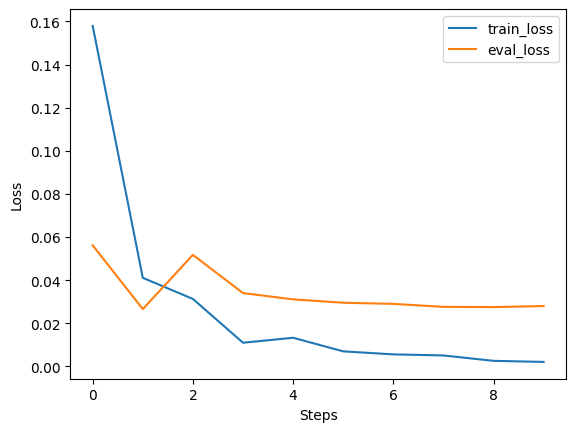

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.plot(train_loss, label="train_loss")
plt.plot(eval_loss, label="eval_loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [32]:
from transformers import AutoModelForMaskedLM, AutoTokenizer
model_path = "/home/UNT/ap1923/ap1923/modelfinetuning/4distractor_modelling"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForMultipleChoice.from_pretrained(model_path)
import torch

In [44]:
import torch
from transformers import AutoTokenizer, AutoModelForMultipleChoice

# context = """You are given the following symptoms joint_pain, skin_peeling, silver_like_dusting, small_dents_in_nails, inflammatory_nails. Your task is to diagnose a disease that best matches the symptoms.
# Both responses accurately diagnose the condition as Psoriasis based on the provided symptoms. However, Response 2 provides a clearer explanation of each symptom's relevance to Psoriasis, making it a more comprehensive and informative answer. A definitive diagnosis by a dermatologist is still necessary for confirmation.
# Both responses suggest psoriasis as the likely diagnosis, and they are consistent in their descriptions of the characteristic symptoms. However, Response 1 provides a clearer explanation of the underlying cause of psoriasis, describing it as an autoimmune condition that causes inflammation and skin cell buildup. Response 2 is more concise but lacks this explanatory detail. An improved response would combine the clarity of Response 1 with the concision of Response 2.
# """

# reply_correct = """Based on the symptoms provided, the likely diagnosis is Psoriasis. This autoimmune condition leads to inflammation and an abnormal buildup of skin cells, causing symptoms such as joint pain, skin peeling, and silver-like dusting. The presence of small dents in nails and inflammatory nails further supports this diagnosis. However, a definitive diagnosis by a dermatologist is necessary for confirmation. This response combines the clarity of Response 1 with the comprehensiveness of Response 2, providing a concise and accurate explanation."""
# reply_incorrect = """
# Based on the symptoms of burning during urination, bladder discomfort, and foul smell of urine, the disease diagnosis is Urinary Tract Infection (UTI). UTIs occur when bacteria, most commonly Escherichia coli, enter the urinary system, causing irritation, inflammation, and infection. The symptoms provided are classic indicators of a UTI, which can be effectively treated with antibiotics and other medications. It is essential to consult a healthcare professional for proper diagnosis and treatment to prevent complications and alleviate symptoms.
# """

context = """You are given the following symptoms muscle_weakness, stiff_neck, swelling_joints, movement_stiffness, painful_walking. Your task is to diagnose a disease that best matches the symptoms.

The symptoms you've described, including muscle weakness, stiff neck, swelling joints, movement stiffness, and painful walking, can be indicative of Rheumatoid Arthritis (RA). RA is an autoimmune disorder that causes inflammation and pain in the joints. The stiff neck and swelling joints are typical signs of joint inflammation, while muscle weakness and movement stiffness can result from chronic pain and reduced mobility. Painful walking further supports this diagnosis, as it is a common symptom of RA affecting the joints in the feet and ankles.

Based on the symptoms provided, I would diagnose the disease as Rheumatoid Arthritis (RA). The symptoms of muscle weakness, stiff neck, swelling joints, movement stiffness, and painful walking are all characteristic of RA. RA is an autoimmune disease that causes inflammation and pain in the joints, leading to stiffness, swelling, and limited mobility. The presence of multiple joint symptoms, including swelling and stiffness, suggests an inflammatory arthritis like RA. A definitive diagnosis would require further evaluation, including laboratory tests and imaging studies.
"""


# reply_correct = """Based on the symptoms provided, Rheumatoid Arthritis (RA) is a likely diagnosis. The combination of muscle weakness, stiff neck, swelling joints, movement stiffness, and painful walking aligns with the characteristic symptoms of RA."""
reply_correct = """Based on the symptoms provided, Rheumatoid Arthritis (RA) is a likely diagnosis. The combination of weakness, stiff neck, swelling joints, are the symptoms of RA."""
# reply_incorrect = """Based on the symptoms provided, Rheumatoid Arthritis (RA) is a likely diagnosis. The combination of headaches, joint pains, vomiting and severe symptoms suggests this diagnosis, although these symptoms do not align with the original findings."""
reply_incorrect = """Based on the symptoms provided, Rheumatoid Arthritis (RA) is a likely diagnosis. The combination of muscle weakness, stiff neck, swelling joints, movement stiffness, and painful walking aligns with the characteristic symptoms of RA."""

inputs = tokenizer(
    [[context, reply_correct],
     [context, reply_incorrect]],
    return_tensors="pt",
    padding=True,
)
labels = torch.tensor(0).unsqueeze(0) 

# outputs = model(**{k: v.unsqueeze(0) for k, v in inputs.items()}, labels=labels)
# logits = outputs.logits
# print(logits)
mcq_inputs = {k: v.unsqueeze(0) for k, v in inputs.items()}
outputs = model(**mcq_inputs)
logits = outputs.logits  # shape: (1,2)
probs = torch.softmax(logits, dim=-1)[0]
prob_correct = probs[0].item()
prob_incorrect = probs[1].item()

print("P(correct reply):   ", prob_correct)
print("P(incorrect reply): ", prob_incorrect)

predicted_choice = logits.argmax().item()
print("Model selected option:", predicted_choice)


P(correct reply):    0.43974265456199646
P(incorrect reply):  0.5602573752403259
Model selected option: 1
